<a href="https://colab.research.google.com/github/sileysa/PCVK26_26_SILEYSA/blob/main/Week3_26.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Langkah 1 - Sel Identitas

In [ ]:
# ===== SEL IDENTITAS - JANGAN DIHAPUS, HARUS SEL PERTAMA =====
import sys, platform, hashlib, datetime, zoneinfo

NAMA = 'Sileysa Faedatul Nuraini'
NIM  = '244107020231'

N = int(NIM[-3:])
PARAM = {
    'b'    : (N % 61) + 20,
    'a'    : round(1.0 + (N % 9) / 10, 1),
    'c'    : (N % 20) + 30,
    'gamma': round(0.4 + (N % 6) * 0.25, 2),
    'bit'  : (N % 6) + 2,
}
waktu = datetime.datetime.now(zoneinfo.ZoneInfo('Asia/Jakarta'))

print('NAMA   :', NAMA)
print('NIM    :', NIM, '| N =', N)
for k, v in PARAM.items():
    print('%-6s :' % k, v)
print('WAKTU  :', waktu.strftime('%Y-%m-%d %H:%M:%S %Z'))
print('SISTEM :', sys.version.split()[0], platform.platform())

kunci = NIM + '|' + waktu.strftime('%Y-%m-%d')
print('TOKEN  :', hashlib.sha256(kunci.encode()).hexdigest()[:16])

NAMA   : Sileysa Faedatul Nuraini
NIM    : 244107020231 | N = 231
b      : 68
a      : 1.6
c      : 41
gamma  : 1.15
bit    : 5
WAKTU  : 2026-09-15 19:30:58 WIB
SISTEM : 3.13.15 Linux-6.6.122+-x86_64-with-glibc2.39
TOKEN  : 4292084a5010d318


# Langkah 2 - Mount Drive & import library

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

BASE = f'/content/drive/MyDrive/PCVK/Images/244107020231'

Mounted at /content/drive


In [ ]:
import cv2 as cv
import numpy as np
import matplotlib.pyplot as plt
import glob
from math import log10, sqrt

def cv2_imshow_rgb(img, title=None):
    if len(img.shape) == 2:
        plt.imshow(img, cmap='gray')
    else:
        plt.imshow(cv.cvtColor(img, cv.COLOR_BGR2RGB))
    if title:
        plt.title(title)
    plt.axis('off')

def show_side_by_side(img_asli, img_hasil, judul_asli='Citra Asli', judul_hasil='Hasil'):
    plt.figure(figsize=(10, 5))
    plt.subplot(1, 2, 1); cv2_imshow_rgb(img_asli, judul_asli)
    plt.subplot(1, 2, 2); cv2_imshow_rgb(img_hasil, judul_hasil + f' (NIM {NIM})')
    plt.tight_layout()
    plt.show()

# Langkah 3 - Fungsi transformasi dasar

In [ ]:
def inverse_citra(img):
    """g(x,y) = 255 - f(x,y)"""
    return 255 - img

def linear_brightness(img, b):
    """g(x,y) = f(x,y) + b, truncate ke [0,255]"""
    return np.clip(img.astype(np.int16) + b, 0, 255).astype(np.uint8)

def contrast_transform(img, a, b=0):
    """g(x,y) = a * f(x,y) + b"""
    return np.clip(a * img.astype(np.float64) + b, 0, 255).astype(np.uint8)

def log_brightness(img, c):
    """s = c * log(1 + r)"""
    s = c * np.log1p(img.astype(np.float64))
    return np.clip(s, 0, 255).astype(np.uint8)

# Langkah 4 - Fungsi grayscale

In [ ]:
def grayscale_average(img_bgr):
    b, g, r = cv.split(img_bgr.astype(np.float64))
    return np.round((r + g + b) / 3).astype(np.uint8)

def grayscale_lightness(img_bgr):
    b, g, r = cv.split(img_bgr.astype(np.float64))
    stacked = np.stack([r, g, b], axis=-1)
    return np.round((stacked.max(axis=-1) + stacked.min(axis=-1)) / 2).astype(np.uint8)

def grayscale_luminance_rec709(img_bgr):
    b, g, r = cv.split(img_bgr.astype(np.float64))
    return np.round(0.21 * r + 0.72 * g + 0.07 * b).astype(np.uint8)

def grayscale_luminance_rec601(img_bgr):
    b, g, r = cv.split(img_bgr.astype(np.float64))
    return np.round(0.299 * r + 0.587 * g + 0.114 * b).astype(np.uint8)

# Langkah 5 - Gamma, bit depth, PSNR

In [ ]:
def gamma_correction(img, gamma):
    result = 255.0 * np.power(img.astype(np.float64) / 255.0, 1.0 / gamma)
    return np.clip(result, 0, 255).astype(np.uint8)

def bit_depth_simulation(img, bit_depth):
    level = 255 / (pow(2, bit_depth) - 1)
    return (np.round(img.astype(np.float64) / level) * level).astype(np.uint8)

def PSNR(img1, img2):
    img1 = img1.astype(np.float64)
    img2 = img2.astype(np.float64)
    mse = np.mean((img1 - img2) ** 2)
    if mse == 0:
        return float('inf')
    return 20 * log10(255.0 / sqrt(mse))

# Langkah 6 - Average denoising & masking

In [ ]:
def average_denoising(list_of_images):
    stack = np.stack([im.astype(np.float64) for im in list_of_images], axis=0)
    return np.mean(stack, axis=0).astype(np.uint8)

def make_rect_mask(shape, boxes):
    mask = np.zeros(shape[:2], dtype=np.uint8)
    for (x1, y1, x2, y2) in boxes:
        cv.rectangle(mask, (x1, y1), (x2, y2), 255, -1)
    return mask

def apply_logic_operator(img, mask, operator='AND'):
    mask_3ch = cv.cvtColor(mask, cv.COLOR_GRAY2BGR) if len(img.shape) == 3 else mask
    if operator == 'AND':
        return cv.bitwise_and(img, mask_3ch)
    elif operator == 'OR':
        return cv.bitwise_or(img, mask_3ch)
    elif operator == 'NOT':
        return cv.bitwise_not(img)
    elif operator == 'NAND':
        return cv.bitwise_not(cv.bitwise_and(img, mask_3ch))
    elif operator == 'XOR':
        return cv.bitwise_xor(img, mask_3ch)
    else:
        raise ValueError('Operator tidak dikenal')

# Tugas 1 - Inverse Citra (KTM1a, KTM1b)

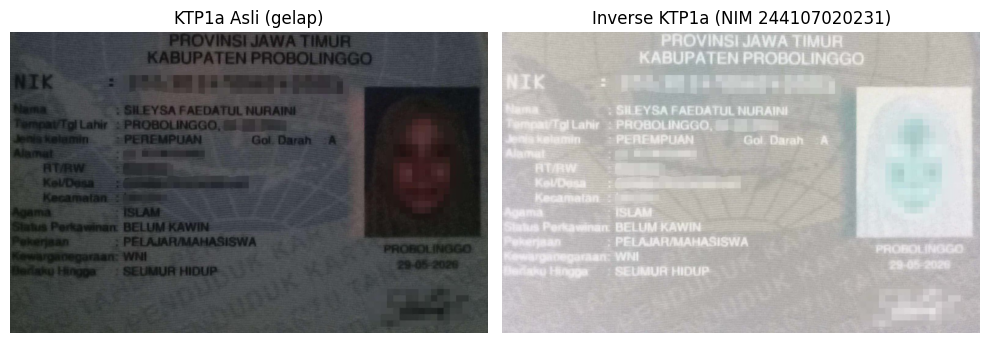

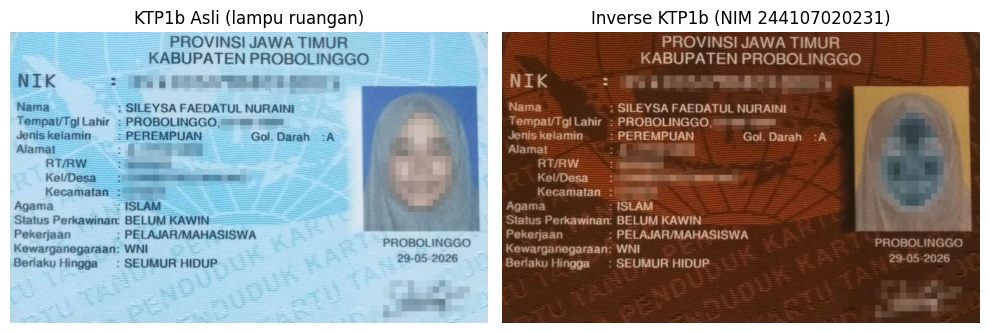

In [ ]:
ktp1a = cv.imread(f'{BASE}/KTP1a.jpg')
ktp1b = cv.imread(f'{BASE}/KTP1b.jpg')

inv_a = inverse_citra(ktp1a)
inv_b = inverse_citra(ktp1b)

show_side_by_side(ktp1a, inv_a, 'KTP1a Asli (gelap)', 'Inverse KTP1a')
show_side_by_side(ktp1b, inv_b, 'KTP1b Asli (lampu ruangan)', 'Inverse KTP1b')

Pada KTM1a yang diambil dalam kondisi ruangan gelap, proses inverse membuat sebagian besar piksel gelap berubah menjadi terang sehingga citra terlihat pucat dan berkabut serta kontrasnya berkurang. Pada KTM1b yang memiliki pencahayaan lebih baik, perbedaan intensitas antarbagian citra masih cukup jelas setelah inverse sehingga hasilnya tetap terlihat kontras.

# Tugas 2 - Transformasi Kontras (a = 1.6)

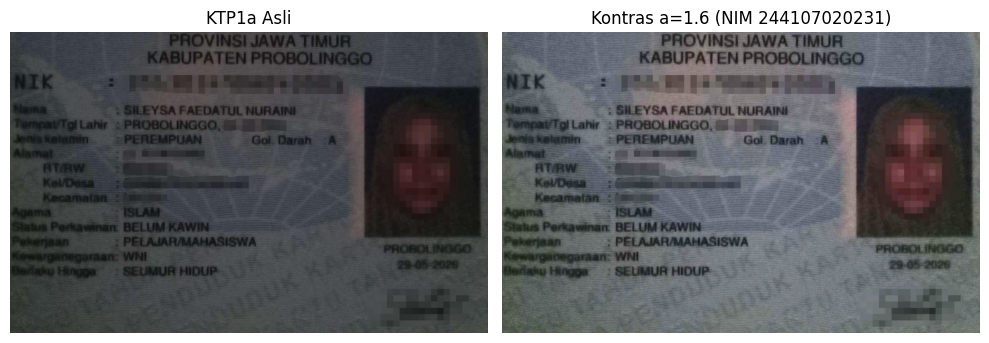

In [ ]:
hasil_kontras = contrast_transform(ktp1a, PARAM['a'], b=0)
show_side_by_side(ktp1a, hasil_kontras, 'KTP1a Asli', f"Kontras a={PARAM['a']}")

# Tugas 3 - Logarithmic vs Linear Brightness (c = 41, b = 68)

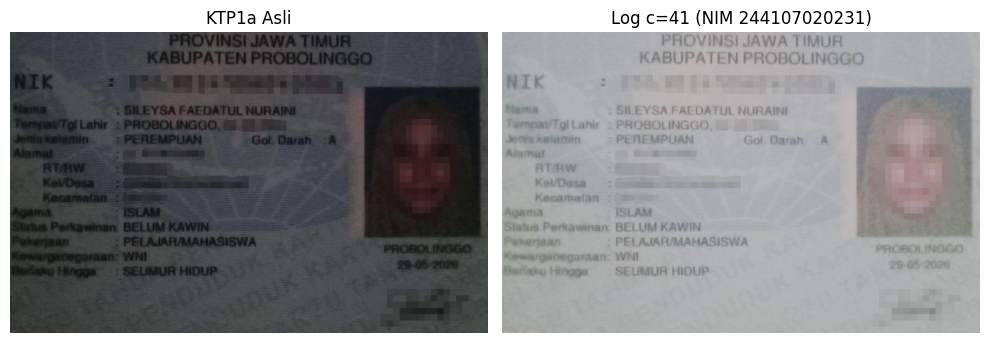

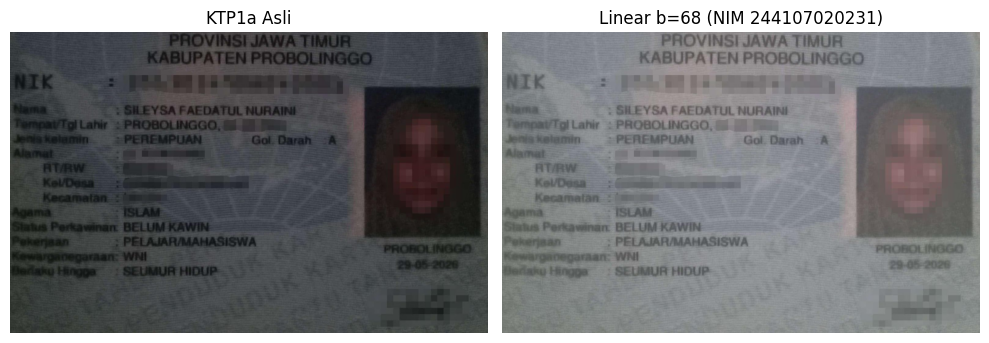

Jumlah pixel clipping (log)   : 0
Jumlah pixel clipping (linier): 0


In [ ]:
hasil_log = log_brightness(ktp1a, PARAM['c'])
hasil_lin = linear_brightness(ktp1a, PARAM['b'])

show_side_by_side(ktp1a, hasil_log, 'KTP1a Asli', f"Log c={PARAM['c']}")
show_side_by_side(ktp1a, hasil_lin, 'KTP1a Asli', f"Linear b={PARAM['b']}")

clip_log = np.sum(hasil_log == 255)
clip_lin = np.sum(hasil_lin == 255)
print('Jumlah pixel clipping (log)   :', clip_log)
print('Jumlah pixel clipping (linier):', clip_lin)

# Tugas 4 - Grayscale: Averaging, Lightness, Luminance (KTM1c)

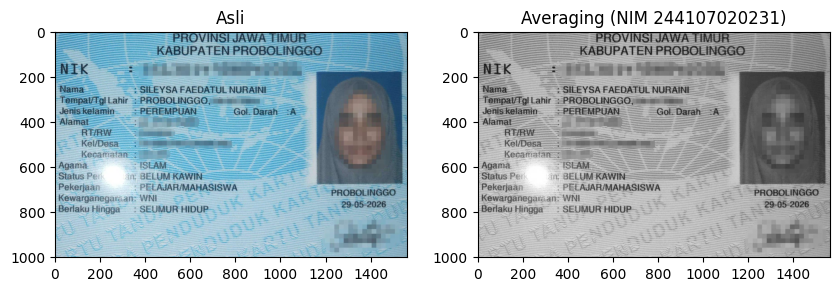

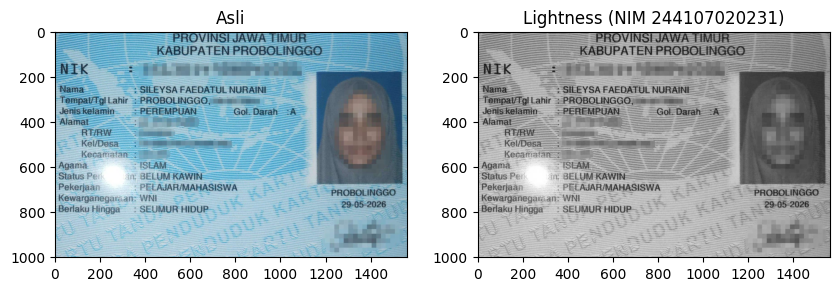

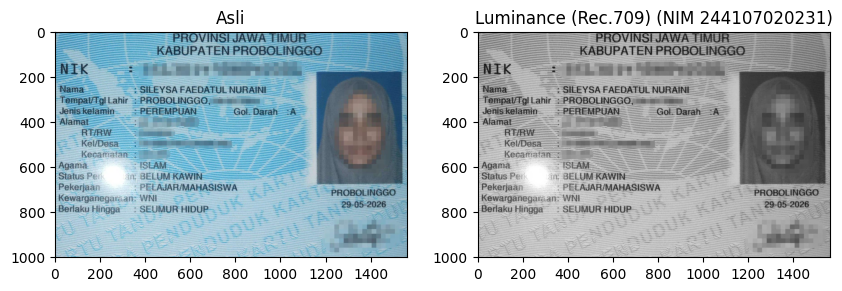

      Metode  Rata-rata Intensitas  Simpangan Baku
0  Averaging            161.111623       42.517207
1  Lightness            157.354179       42.184107
2  Luminance            161.214794       42.931972


In [ ]:
ktp1c = cv.imread(f'{BASE}/KTP1c.jpg')

gray_avg = grayscale_average(ktp1c)
gray_lig = grayscale_lightness(ktp1c)
gray_lum = grayscale_luminance_rec709(ktp1c)  # pilih 1 standar, konsisten dipakai

for nama, hasil in [('Averaging', gray_avg), ('Lightness', gray_lig), ('Luminance (Rec.709)', gray_lum)]:
    plt.figure(figsize=(10, 5))
    plt.subplot(1, 2, 1); plt.imshow(cv.cvtColor(ktp1c, cv.COLOR_BGR2RGB)); plt.title('Asli')
    plt.subplot(1, 2, 2); plt.imshow(hasil, cmap='gray'); plt.title(f'{nama} (NIM {NIM})')
    plt.show()

import pandas as pd
tabel = pd.DataFrame({
    'Metode': ['Averaging', 'Lightness', 'Luminance'],
    'Rata-rata Intensitas': [gray_avg.mean(), gray_lig.mean(), gray_lum.mean()],
    'Simpangan Baku': [gray_avg.std(), gray_lig.std(), gray_lum.std()],
})
print(tabel)

# Tugas 5 - Isolasi Satu Warna (HSV) pada OBJ1

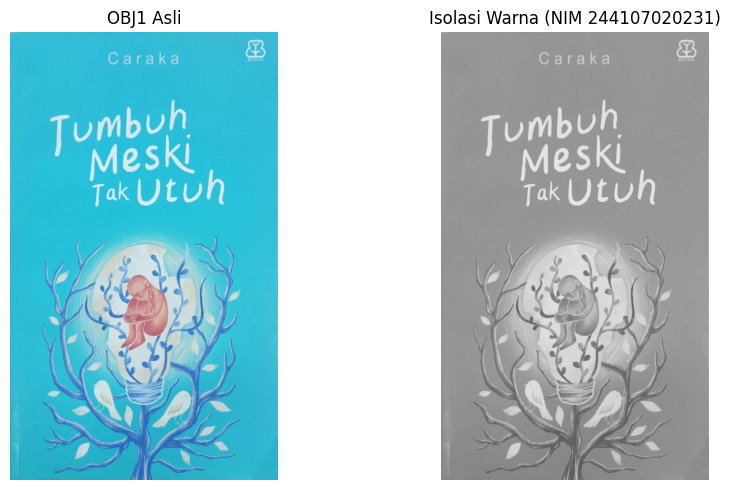

In [ ]:
obj1 = cv.imread(f'{BASE}/OBJ1.jpg')
hsv = cv.cvtColor(obj1, cv.COLOR_BGR2HSV)

lower_hsv = np.array([0, 100, 100])
upper_hsv = np.array([10, 255, 255])

mask_warna = cv.inRange(hsv, lower_hsv, upper_hsv)
gray_bg = cv.cvtColor(cv.cvtColor(obj1, cv.COLOR_BGR2GRAY), cv.COLOR_GRAY2BGR)
hasil_isolasi = np.where(mask_warna[..., None].astype(bool), obj1, gray_bg)

show_side_by_side(obj1, hasil_isolasi, 'OBJ1 Asli', 'Isolasi Warna')

# Tugas 6 - Gamma Correction (mulai dari gamma = 1.15)

 Gamma Correction pada citra 
----------------------------------
Masukkan nilai Gamma (mulai dari 1.15): 2.50


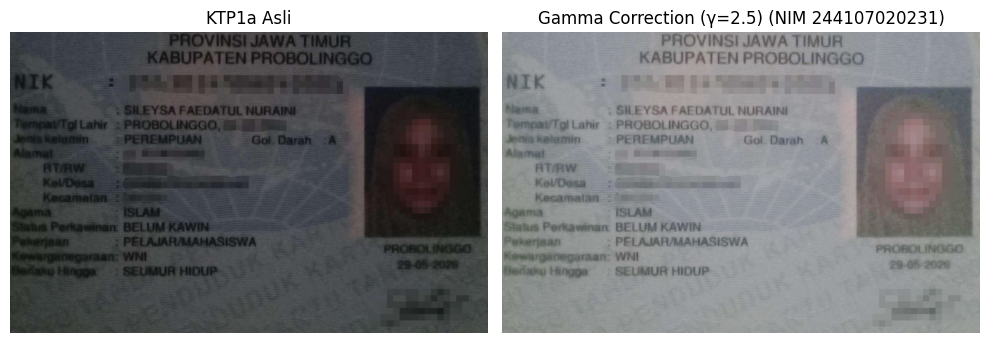

In [ ]:
print(' Gamma Correction pada citra ')
print('----------------------------------')
try:
    gamma_input = float(input(f"Masukkan nilai Gamma (mulai dari {PARAM['gamma']}): "))
except ValueError:
    print('Error, not a number')
    gamma_input = PARAM['gamma']

hasil_gamma = gamma_correction(ktp1a, gamma_input)
show_side_by_side(ktp1a, hasil_gamma, 'KTP1a Asli', f'Gamma Correction (γ={gamma_input})')

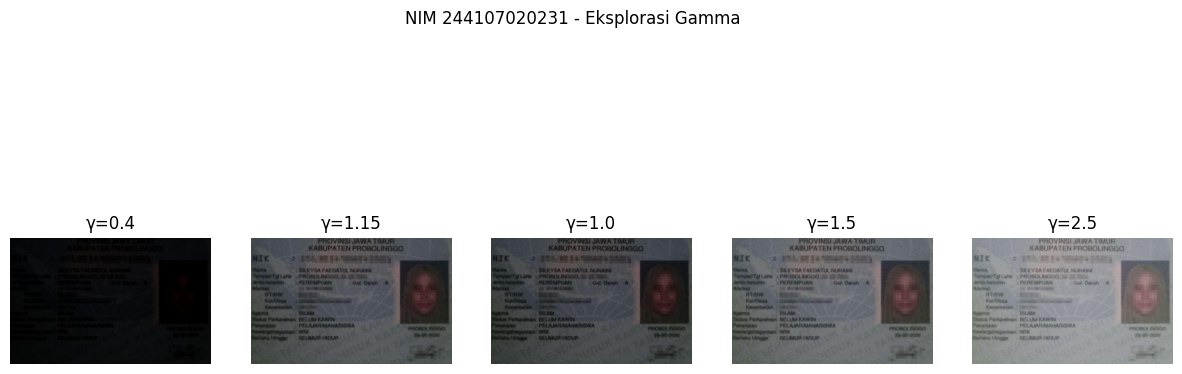

In [ ]:
nilai_gamma_dicoba = [0.4, PARAM['gamma'], 1.0, 1.5, 2.5]  # >>> sesuaikan hasil eksplorasi <

plt.figure(figsize=(15, 6))
for i, g in enumerate(nilai_gamma_dicoba):
    hasil = gamma_correction(ktp1a, g)
    plt.subplot(1, len(nilai_gamma_dicoba), i + 1)
    plt.imshow(cv.cvtColor(hasil, cv.COLOR_BGR2RGB))
    plt.title(f'γ={g}')
    plt.axis('off')
plt.suptitle(f'NIM {NIM} - Eksplorasi Gamma')
plt.show()

# Tugas 7 - Simulasi Image Depth (KTM1b, bit = 5)

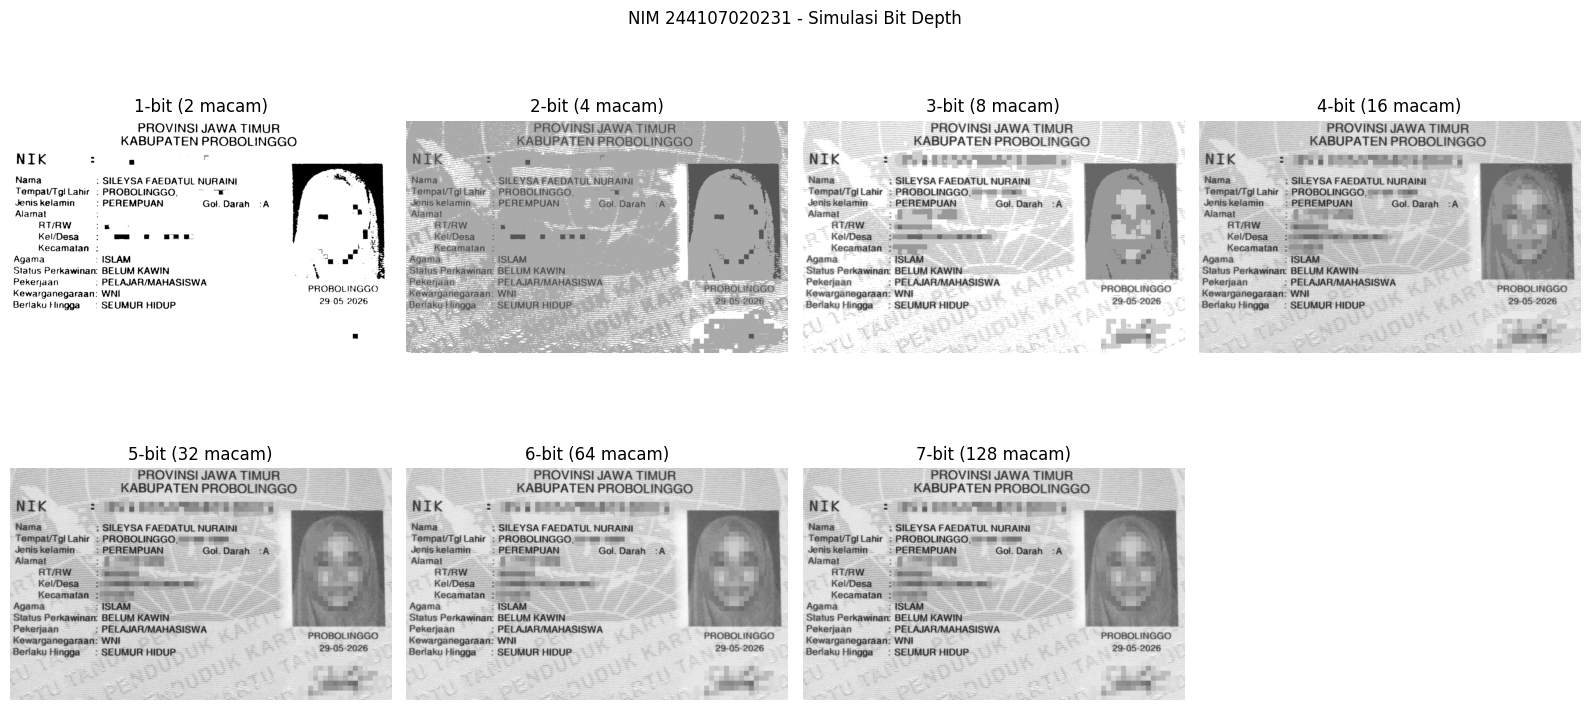

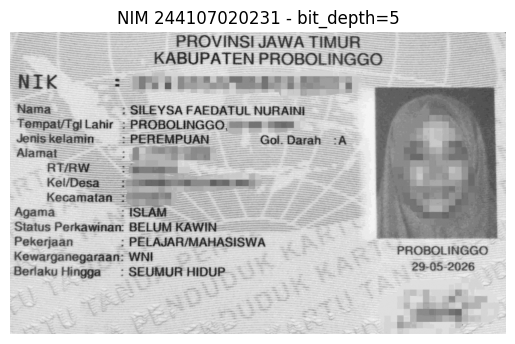

In [ ]:
ktp1b_gray = cv.imread(f'{BASE}/KTP1b.jpg', cv.IMREAD_GRAYSCALE)

plt.figure(figsize=(16, 8))
for i, bit in enumerate(range(1, 8)):
    hasil_bit = bit_depth_simulation(ktp1b_gray, bit)
    plt.subplot(2, 4, i + 1)
    plt.imshow(hasil_bit, cmap='gray')
    plt.title(f'{bit}-bit ({2**bit} macam)')
    plt.axis('off')
plt.suptitle(f'NIM {NIM} - Simulasi Bit Depth')
plt.tight_layout()
plt.show()

hasil_bit_nim = bit_depth_simulation(ktp1b_gray, PARAM['bit'])
plt.imshow(hasil_bit_nim, cmap='gray'); plt.title(f"NIM {NIM} - bit_depth={PARAM['bit']}"); plt.axis('off'); plt.show()

# Tugas 8 - Average Denoising & PSNR

In [ ]:
import cv2 as cv
import glob
original_galaxy = cv.imread('/content/drive/MyDrive/PCVK/Images/galaxy.jpg')
cv_img = []
for fpath in sorted(glob.glob('/content/drive/MyDrive/PCVK/Images/noises/*.jpg')):
    cv_img.append(cv.imread(fpath))

print('Jumlah citra noise terbaca:', len(cv_img))

Jumlah citra noise terbaca: 100


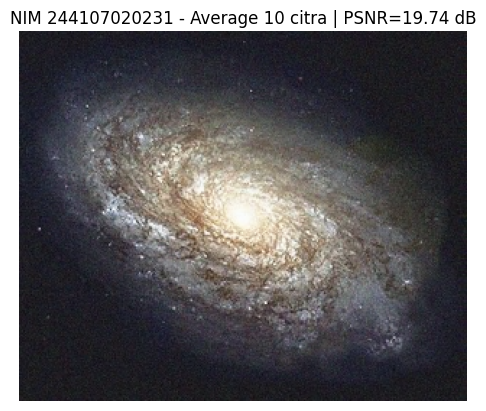

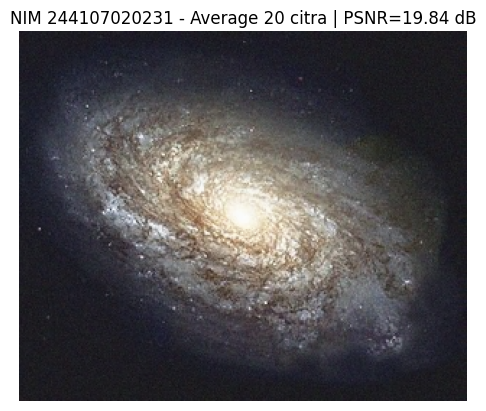

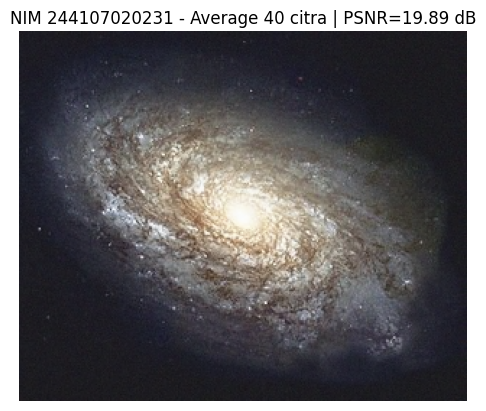

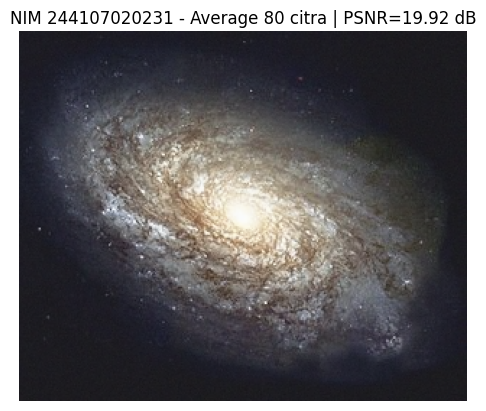

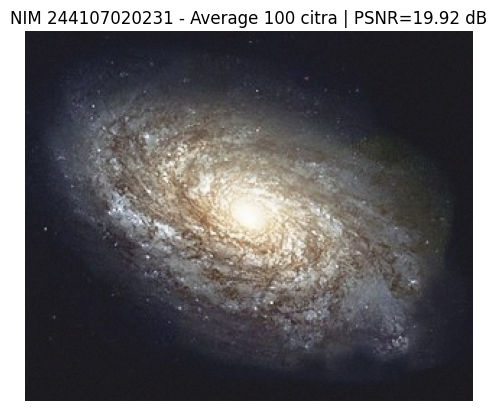

   Jumlah Citra  PSNR (dB)
0            10  19.735622
1            20  19.840488
2            40  19.892767
3            80  19.915894
4           100  19.921961


In [ ]:
jumlah_citra_list = [10, 20, 40, 80, 100]
hasil_psnr = {}

for n_citra in jumlah_citra_list:
    denoised = average_denoising(cv_img[:n_citra])
    psnr_val = PSNR(original_galaxy, denoised)
    hasil_psnr[n_citra] = psnr_val
    plt.imshow(cv.cvtColor(denoised, cv.COLOR_BGR2RGB))
    plt.title(f'NIM {NIM} - Average {n_citra} citra | PSNR={psnr_val:.2f} dB')
    plt.axis('off')
    plt.show()

import pandas as pd
tabel_psnr = pd.DataFrame({
    'Jumlah Citra': jumlah_citra_list,
    'PSNR (dB)': [hasil_psnr[n] for n in jumlah_citra_list],
})
print(tabel_psnr)

# Tugas 9 - Image Masking (KTM1d)

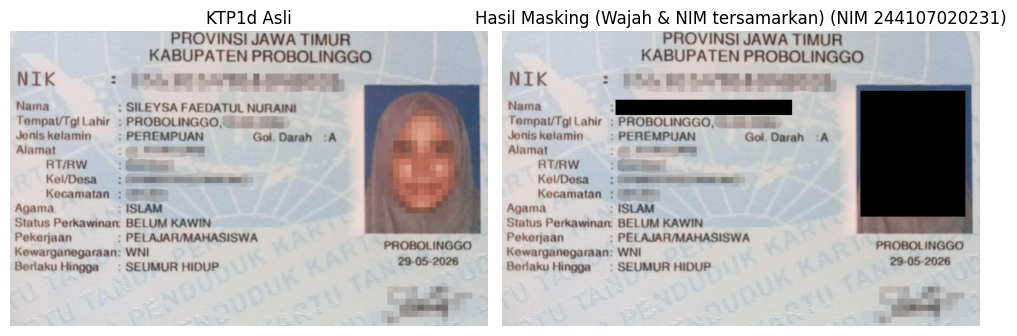

Koordinat box wajah: (1200, 200, 1550, 620)
Koordinat box NIM  : (380, 230, 970, 280)


In [ ]:
ktp1d = cv.imread(f'{BASE}/KTP1d.jpg')

box_wajah = (1200, 200, 1550, 620)
box_nim   = (380, 230, 970, 280)

mask_penyamaran = make_rect_mask(ktp1d.shape, [box_wajah, box_nim])
mask_inv = cv.bitwise_not(mask_penyamaran)
hasil_masking = apply_logic_operator(ktp1d, mask_inv, 'AND')

show_side_by_side(ktp1d, hasil_masking, 'KTP1d Asli', 'Hasil Masking (Wajah & NIM tersamarkan)')
print('Koordinat box wajah:', box_wajah)
print('Koordinat box NIM  :', box_nim)

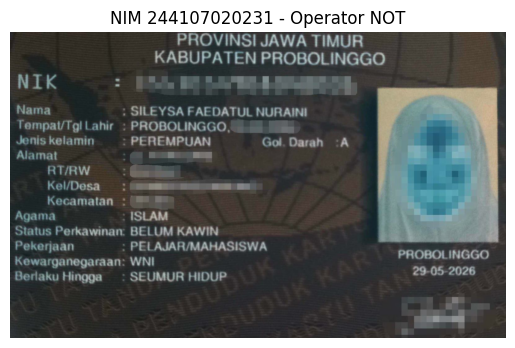

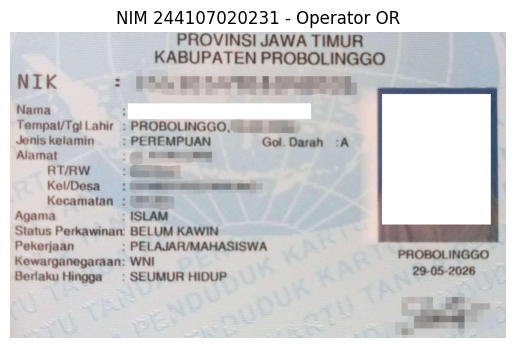

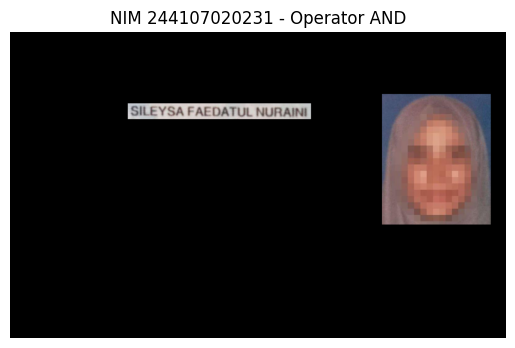

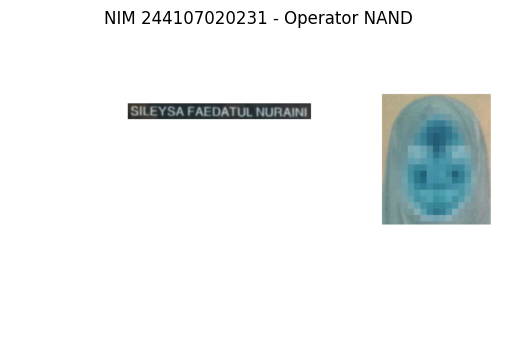

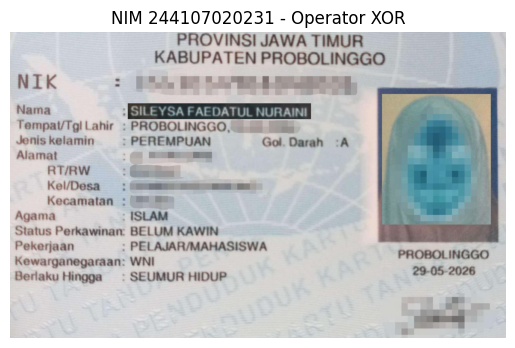

In [ ]:
for op in ['NOT', 'OR', 'AND', 'NAND', 'XOR']:
    hasil_op = apply_logic_operator(ktp1d, mask_inv if op == 'NOT' else mask_penyamaran, op)
    plt.imshow(cv.cvtColor(hasil_op, cv.COLOR_BGR2RGB))
    plt.title(f'NIM {NIM} - Operator {op}')
    plt.axis('off')
    plt.show()

# Tugas 10 - Perbaikan Foto Malam Hari (NIGHT1)

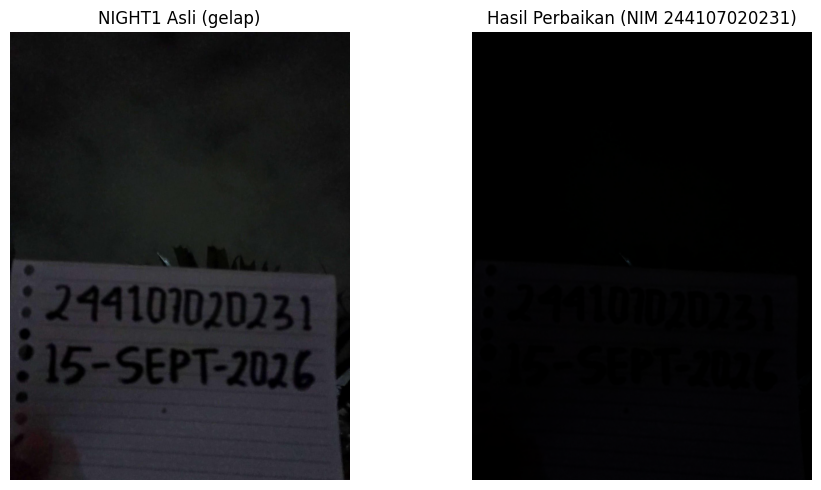

In [ ]:
night1 = cv.imread(f'{BASE}/NIGHT1.jpg')

# >>> pilih metode & parameter terbaik hasil eksperimen Anda <
hasil_night = gamma_correction(night1, gamma=0.4)

show_side_by_side(night1, hasil_night, 'NIGHT1 Asli (gelap)', 'Hasil Perbaikan')